# Swarm Chart

This section showcases the swarm chart. It contains examples of how to create swarm charts using the [datachart.charts.SwarmChart](../../../references/charts/#datachart.charts.SwarmChart) function.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-swarm-chart), which maps common tasks to the parameter or style attribute that does the job.

As mentioned above, the swarm charts are created using the `SwarmChart` function found in the [datachart.charts](../../../references/charts/) module. Let's import it:

In [1]:
from datachart.charts import SwarmChart

## Swarm Chart Input Attributes

The `SwarmChart` function accepts keyword arguments for chart configuration. The main argument is `data`, which contains the data points. For a single swarm chart, `data` is a list of dictionaries; the points that share a `label` form one group. For multiple swarm charts, `data` is a list of lists.

```python
SwarmChart(
    data=[{                                             # A list of data points (or list of lists for multiple charts)
        "label": str,                                   # The category label
        "value": Union[int, float],                     # The numeric value
    }],
    style={                                             # The style of the points (optional)
        "plot_swarm_color":         Union[str, None],       # The point color
        "plot_swarm_alpha":         Union[float, None],     # The alpha of the points
        "plot_swarm_size":          Union[int, float, None], # The point size
        "plot_swarm_marker":        Union[str, None],       # The point marker shape
        "plot_swarm_edge_width":    Union[int, float, None], # The edge width of the points
        "plot_swarm_edge_color":    Union[str, None],       # The edge color of the points
        "plot_swarm_zorder":        Union[int, float, None], # The zorder of the points
    },
    title: Union[str, None],                            # The chart title (optional)
    xlabel: Union[str, None],                           # The x-axis label (optional)
    ylabel: Union[str, None],                           # The y-axis label (optional)
    subtitle: Union[str, List[str], None],              # The subtitle(s), used as legend labels (optional)
    emphasis: Union[str, List[str], None],              # The emphasis role(s), aligned with the group labels (optional)
    mode: Union[str, None],                             # "swarm" (the default) or "strip" (optional)
    jitter: Union[float, None],                         # The strip jitter width, a fraction of the category width (optional)
    orientation: Union[str, None],                      # "vertical" (the default) or "horizontal" (optional)
    scaley: Union[str, None],                           # The value axis scale (optional)
    figsize: Union[Tuple[float, float], None],          # The figure size (optional)
    show_legend: Union[bool, None],                     # Whether to show the legend (optional)
    show_grid: Union[str, None],                        # Which grid lines to show (optional)
    subplots: Union[bool, None],                        # Whether to draw each chart in its own subplot (optional)
    max_cols: Union[int, None],                         # The maximum number of subplot columns (optional)
    sharex: Union[bool, None],                          # Whether the subplots share the x-axis (optional)
    sharey: Union[bool, None],                          # Whether the subplots share the y-axis (optional)
    hlines: Union[dict, List[dict], None],              # The horizontal reference lines (optional)
    vlines: Union[dict, List[dict], None],              # The vertical reference lines (optional)
    label: Union[str, None],                            # The key name in `data` holding the label (optional)
    value: Union[str, None],                            # The key name in `data` holding the value (optional)
)
```

For more details, see the [datachart.charts.SwarmChart](../../../references/charts/#datachart.charts.SwarmChart) function.

## Basics

The examples in this guide share one dataset: the body mass of the 342 penguins of the [Palmer penguins](https://allisonhorst.github.io/palmerpenguins/) dataset (CC0), three species measured on the islands of the Palmer Archipelago in Antarctica. The data is hard-coded in a hidden cell, which keeps the sex and the flipper length of every penguin alongside its species — the later sections and examples reuse them. `chart_data` holds the body mass (in g) of every penguin, labeled with its species.

In [2]:
# the 342 Palmer penguins with a recorded body mass, grouped by species and sex
PENGUINS = [
    {
        "species": "Adelie",
        "sex": "Female",
        "body_mass": [
            3800, 3250, 3450, 3625, 3200, 3700, 3450, 3325, 3400, 3800, 3800, 3200, 3150,
            3250, 3300, 3325, 3550, 3300, 3150, 3100, 3000, 3450, 3500, 3450, 2900, 3550,
            2850, 3150, 3600, 2850, 3350, 3050, 3600, 3550, 3700, 3700, 3550, 3200, 3800,
            3350, 3500, 3600, 3550, 3400, 3300, 3700, 2900, 3725, 3075, 2925, 3750, 3175,
            3825, 3200, 3900, 2900, 3350, 3150, 3450, 3050, 3275, 3050, 3325, 3500, 3425,
            3175, 3400, 3400, 3050, 3000, 3475, 3450, 3700,
        ],
        "flipper_length": [
            186, 195, 193, 181, 182, 185, 195, 184, 174, 189, 187, 187, 172, 178, 188, 195,
            180, 181, 182, 186, 185, 190, 186, 190, 187, 186, 181, 185, 185, 184, 195, 190,
            190, 196, 190, 191, 187, 189, 187, 191, 189, 190, 202, 185, 187, 190, 178, 192,
            183, 193, 199, 181, 198, 193, 191, 188, 189, 187, 176, 186, 191, 191, 190, 193,
            187, 191, 185, 193, 188, 192, 184, 195, 187,
        ],
    },
    {
        "species": "Adelie",
        "sex": "Male",
        "body_mass": [
            3750, 3650, 4675, 3800, 4400, 4500, 4200, 3600, 3950, 3800, 3550, 3950, 3900,
            3900, 4150, 3950, 4650, 3900, 4400, 4600, 3425, 4150, 4300, 4050, 3700, 3800,
            3750, 4400, 4050, 3950, 4100, 4450, 3900, 4150, 4250, 3900, 4000, 4700, 4200,
            3550, 3800, 3950, 4300, 4450, 4300, 4350, 4100, 4725, 4250, 3550, 3900, 4775,
            4600, 4275, 4075, 3775, 3325, 3500, 3875, 4000, 4300, 4000, 3500, 4475, 3900,
            3975, 4250, 3475, 3725, 3650, 4250, 3750, 4000,
        ],
        "flipper_length": [
            181, 190, 195, 191, 198, 197, 194, 180, 185, 180, 183, 180, 178, 184, 196, 190,
            184, 195, 196, 190, 182, 191, 188, 200, 191, 193, 194, 195, 192, 192, 188, 198,
            190, 197, 195, 184, 195, 196, 193, 194, 190, 189, 205, 186, 208, 196, 192, 203,
            190, 184, 190, 197, 191, 197, 196, 199, 189, 198, 202, 199, 195, 210, 197, 199,
            190, 200, 193, 187, 190, 185, 190, 193, 201,
        ],
    },
    {
        "species": "Adelie",
        "sex": None,
        "body_mass": [
            3475, 4250, 3300, 3700, 2975,
        ],
        "flipper_length": [
            193, 190, 186, 180, 179,
        ],
    },
    {
        "species": "Chinstrap",
        "sex": "Female",
        "body_mass": [
            3500, 3525, 3950, 3250, 4150, 3800, 3700, 3575, 3700, 3450, 3600, 2900, 3300,
            3400, 3700, 3200, 3350, 3900, 3850, 2700, 3650, 3500, 3675, 3400, 3675, 3325,
            3600, 3350, 3250, 3525, 3650, 3650, 3400, 3775,
        ],
        "flipper_length": [
            192, 188, 198, 178, 195, 193, 185, 190, 181, 190, 181, 187, 195, 200, 191, 187,
            187, 199, 195, 192, 187, 196, 196, 190, 198, 199, 193, 187, 191, 194, 189, 195,
            202, 198,
        ],
    },
    {
        "species": "Chinstrap",
        "sex": "Male",
        "body_mass": [
            3900, 3650, 3725, 3750, 3700, 3775, 4050, 4050, 3300, 4400, 3400, 3800, 4150,
            3800, 4550, 4300, 4100, 3600, 4800, 4500, 3950, 3550, 4450, 4300, 3250, 3950,
            4050, 3450, 4050, 3800, 3950, 4000, 3775, 4100,
        ],
        "flipper_length": [
            196, 193, 197, 197, 198, 194, 201, 201, 197, 195, 191, 193, 197, 200, 205, 201,
            203, 195, 210, 205, 210, 196, 201, 212, 187, 201, 203, 197, 203, 202, 206, 207,
            193, 210,
        ],
    },
    {
        "species": "Gentoo",
        "sex": "Female",
        "body_mass": [
            4500, 4450, 4550, 4800, 4400, 4650, 4650, 4200, 4150, 4800, 5000, 4400, 5000,
            4600, 4700, 5050, 5150, 4950, 4350, 3950, 4300, 4900, 4200, 5100, 4850, 4400,
            4900, 4300, 4450, 4200, 4400, 4700, 4700, 4750, 5200, 4700, 4600, 4750, 4625,
            4725, 4750, 4600, 4875, 4950, 4750, 4850, 4875, 4625, 4850, 4975, 4700, 4575,
            5000, 4650, 4375, 4925, 4850, 5200,
        ],
        "flipper_length": [
            211, 210, 210, 211, 209, 214, 214, 210, 210, 209, 215, 213, 215, 210, 209, 207,
            220, 213, 208, 208, 210, 217, 210, 213, 210, 210, 217, 208, 208, 208, 214, 219,
            220, 216, 217, 216, 209, 215, 212, 212, 212, 218, 212, 218, 212, 214, 222, 203,
            219, 215, 210, 208, 216, 213, 217, 214, 215, 212,
        ],
    },
    {
        "species": "Gentoo",
        "sex": "Male",
        "body_mass": [
            5700, 5700, 5400, 5200, 5150, 5550, 5850, 5850, 6300, 5350, 5700, 5050, 5100,
            5650, 5550, 5250, 6050, 5400, 5250, 5350, 5700, 4750, 5550, 5400, 5300, 5300,
            5000, 5050, 5000, 5550, 5300, 5650, 5700, 5800, 5550, 5000, 5100, 5800, 6000,
            5950, 5450, 5350, 5600, 5300, 5550, 5400, 5650, 5200, 4925, 5250, 5600, 5500,
            5500, 5500, 5500, 5950, 5500, 5850, 6000, 5750, 5400,
        ],
        "flipper_length": [
            230, 218, 215, 219, 215, 216, 213, 217, 221, 222, 218, 215, 215, 215, 220, 222,
            230, 220, 219, 208, 225, 216, 222, 225, 215, 220, 225, 220, 220, 224, 221, 231,
            230, 229, 223, 221, 221, 230, 220, 223, 221, 224, 228, 218, 230, 228, 224, 226,
            216, 225, 228, 228, 215, 219, 209, 229, 230, 230, 222, 222, 213,
        ],
    },
    {
        "species": "Gentoo",
        "sex": None,
        "body_mass": [
            4100, 4650, 4725, 4875,
        ],
        "flipper_length": [
            216, 214, 216, 217,
        ],
    },
]

chart_data = [
    {"label": penguin["species"], "value": mass}
    for penguin in PENGUINS
    for mass in penguin["body_mass"]
]
flipper_data = [
    {"label": penguin["species"], "value": length}
    for penguin in PENGUINS
    for length in penguin["flipper_length"]
]

The data is a flat list of dictionaries, one per data point, each with a `label` and a `value`. The points that share a `label` are grouped into one swarm, so three species give three swarms:

In [3]:
chart_data[:3]

[{'label': 'Adelie', 'value': 3800},
 {'label': 'Adelie', 'value': 3250},
 {'label': 'Adelie', 'value': 3450}]

**Basic example.** Only the `data` argument is required to draw the swarm chart. Every penguin is one point at its species' position, and the points spread sideways just far enough not to cover each other, so the width of a swarm at any height shows how many penguins weigh that much.

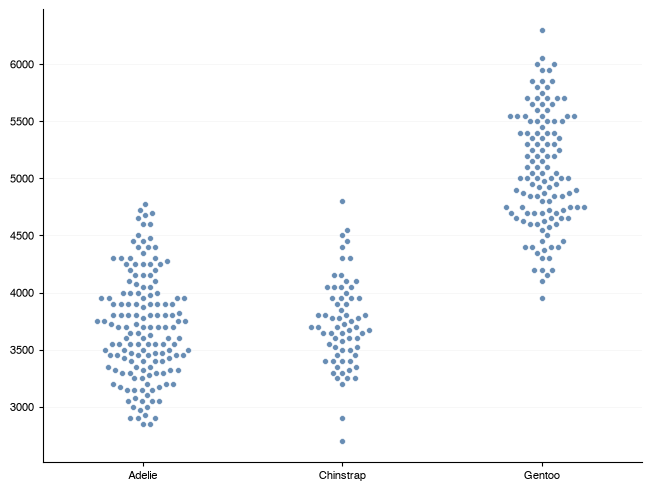

In [4]:
SwarmChart(
    # add the data to the chart
    data=chart_data
).show()

## Customizing the Swarm Chart

Every customization is either a keyword argument of `SwarmChart` or a `plot_swarm_*` attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                  | Use                                                                     | See |
| :------------------------------------------ | :---------------------------------------------------------------------- | :-- |
| add a title and axis labels                 | `title`, `xlabel`, `ylabel`                                             | [Title and axis labels](#title-and-axis-labels) |
| resize the figure                           | `figsize`                                                               | [Figure size and grid](#figure-size-and-grid) |
| show the grid lines                         | `show_grid`                                                             | [Figure size and grid](#figure-size-and-grid) |
| change the point color, size or transparency | `style={"plot_swarm_color": ..., "plot_swarm_size": ..., "plot_swarm_alpha": ...}` | [Point style](#point-style) |
| change the point marker or edge             | `style={"plot_swarm_marker": ..., "plot_swarm_edge_color": ..., ...}`   | [Point style](#point-style) |
| jitter the points instead of packing them   | `mode`, `jitter`                                                        | [Swarm and strip modes](#swarm-and-strip-modes) |
| draw the swarms horizontally                | `orientation`                                                           | [Swarm orientation](#swarm-orientation) |
| highlight one group, mute the rest          | `emphasis`                                                              | [Emphasis](#emphasis) |
| draw a threshold or reference line          | `hlines`, `vlines`                                                      | [Reference lines](#reference-lines) |
| put the points on top of a box plot         | `Panel`                                                                 | [Overlaying a box plot](#overlaying-a-box-plot) |
| draw several datasets on one chart          | `data` as a list of lists, `subtitle`                                   | [Multiple Swarm Charts](#multiple-swarm-charts) |
| draw each dataset in its own subplot        | `subplots`, `max_cols`, `sharex`, `sharey`                              | [Subplots](#subplots) |
| use a logarithmic value axis                | `scaley`                                                                | [Logarithmic scale](#logarithmic-scale) |
| save the chart to a file                    | `save_figure`                                                           | [Saving the Chart as an Image](#saving-the-chart-as-an-image) |

The full list of style attributes is in the [datachart.typings.SwarmStyleAttrs](../../../references/typings/#datachart.typings.SwarmStyleAttrs) type; the full list of parameters is in the [datachart.charts.SwarmChart](../../../references/charts/#datachart.charts.SwarmChart) reference.

### Title and axis labels

To add the chart title and axis labels, add the `title`, `xlabel` and `ylabel` attributes.

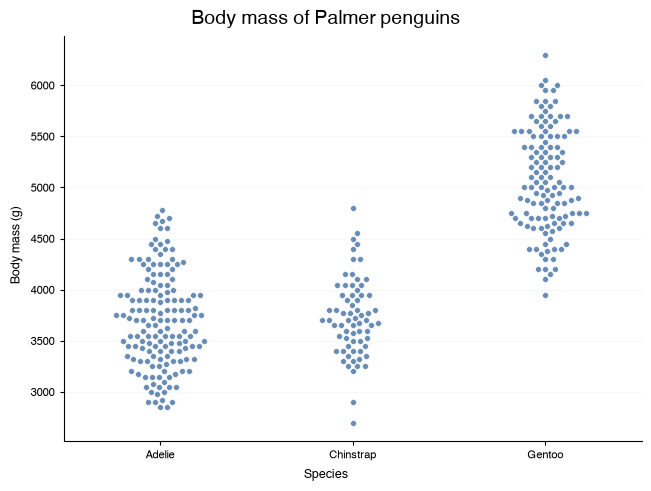

In [5]:
SwarmChart(
    data=chart_data,
    # add the title
    title="Body mass of Palmer penguins",
    # add the x and y axis labels
    xlabel="Species",
    ylabel="Body mass (g)",
).show()

### Figure size and grid

To change the figure size, add the `figsize` attribute. The `figsize` attribute can be a tuple (width, height), values are in inches. The `datachart` package provides a [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE) constant, which contains predefined figure sizes. To show the grid lines, add the `show_grid` attribute, which supports the values of the [datachart.constants.SHOW_GRID](../../../references/constants/#datachart.constants.SHOW_GRID) constant.

In [6]:
from datachart.constants import FIG_SIZE, SHOW_GRID

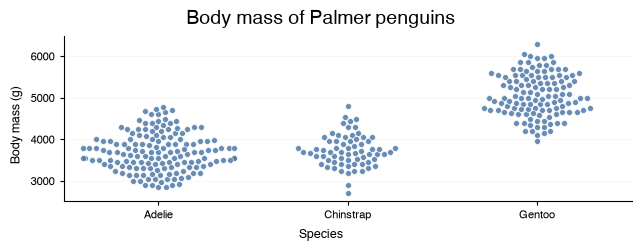

In [7]:
SwarmChart(
    data=chart_data,
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    # add to determine the figure size
    figsize=FIG_SIZE.FULL_SHORT,
    # add to show the grid lines
    show_grid=SHOW_GRID.Y,
).show()

### Point style

To change the point style, add the `style` attribute with the corresponding attributes. The supported attributes are shown in the [datachart.typings.SwarmStyleAttrs](../../../references/typings/#datachart.typings.SwarmStyleAttrs) type, which contains the following attributes:

| Attribute | Description |
| :-------- | :---------- |
| `plot_swarm_color` | The point color. |
| `plot_swarm_alpha` | The alpha of the points. |
| `plot_swarm_size` | The point size, in points squared. The swarm packs the points from this size, so larger points spread wider. |
| `plot_swarm_marker` | The point marker shape; see [datachart.constants.LINE_MARKER](../../../references/constants/#datachart.constants.LINE_MARKER). |
| `plot_swarm_edge_width` | The edge width of the points. |
| `plot_swarm_edge_color` | The edge color of the points. |
| `plot_swarm_zorder` | The zorder of the points. |

In [8]:
from datachart.constants import LINE_MARKER

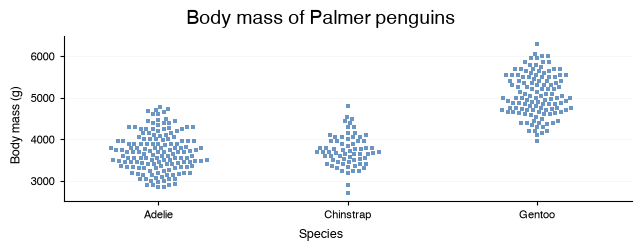

In [9]:
SwarmChart(
    data=chart_data,
    # define the style of the points
    style={
        "plot_swarm_color": "#08519c",
        "plot_swarm_size": 12,
        "plot_swarm_alpha": 0.6,
        "plot_swarm_marker": LINE_MARKER.SQUARE,
        "plot_swarm_edge_color": "#08519c",
        "plot_swarm_edge_width": 0,
    },
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Swarm and strip modes

The `mode` attribute chooses how the points of a group spread across the category width. It supports the values of the [datachart.constants.SWARM_MODE](../../../references/constants/#datachart.constants.SWARM_MODE) constant:

| Value | Description |
| :---- | :---------- |
| `"swarm"` | The points are packed so none overlap, from the point size at the moment the chart is drawn (the default). Axis limits changed on the figure afterwards can shift the spacing. |
| `"strip"` | The points are jittered uniformly across the category width; `jitter` sets the width of the band as a fraction of the category width (0.4 by default). The jitter is seeded, so the same data draws the same chart. |

The strip mode is the faster choice for many thousands of points, where a swarm would fill its whole width anyway.

In [10]:
from datachart.constants import SWARM_MODE

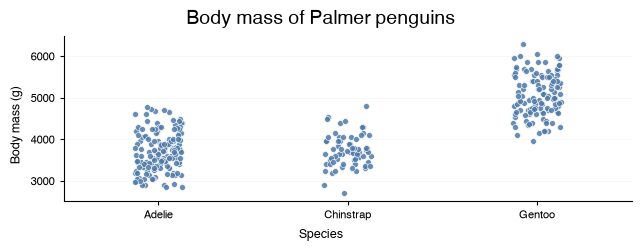

In [11]:
SwarmChart(
    data=chart_data,
    # jitter the points instead of packing them
    mode=SWARM_MODE.STRIP,
    # narrow the jitter band to a quarter of the category width
    jitter=0.25,
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Swarm orientation

To change the orientation of the swarms, add the `orientation` attribute, which supports the following values:

| Value | Description |
| :---- | :---------- |
| `"vertical"` | The swarms are vertical, one per category along the x-axis (the default). |
| `"horizontal"` | The swarms are horizontal, one per category along the y-axis. |

The `datachart` package provides the [datachart.constants.ORIENTATION](../../../references/constants/#datachart.constants.ORIENTATION) constant with these values.

In [12]:
from datachart.constants import ORIENTATION

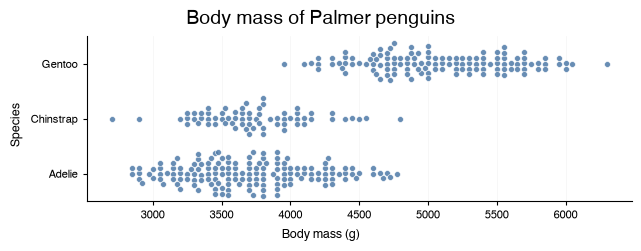

In [13]:
SwarmChart(
    data=chart_data,
    # change the orientation of the swarms
    orientation=ORIENTATION.HORIZONTAL,
    title="Body mass of Palmer penguins",
    # swap the axis labels to match the orientation
    xlabel="Body mass (g)",
    ylabel="Species",
    figsize=FIG_SIZE.FULL_SHORT,
    # the value axis is now the x-axis
    show_grid=SHOW_GRID.X,
).show()

### Emphasis

To draw attention to one group, add the `emphasis` attribute. The `emphasis` list aligns with the group **labels** of one call, in the order the labels first appear in the data — here Adelie, Chinstrap, Gentoo. Each entry is one of the following roles:

| Role | Description |
| :--- | :---------- |
| `"background"` | Mutes the group's points into the theme's muted color and alpha. |
| `"highlight"` | Bolds the edges of the group's points. |
| `None` | Leaves the group unchanged. |

A single value applies to every group. The [datachart.constants.EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS) constant holds the roles; the [highlighting guide](../../styling/highlighting.ipynb) covers emphasis across chart types and themes.

In [14]:
from datachart.constants import EMPHASIS

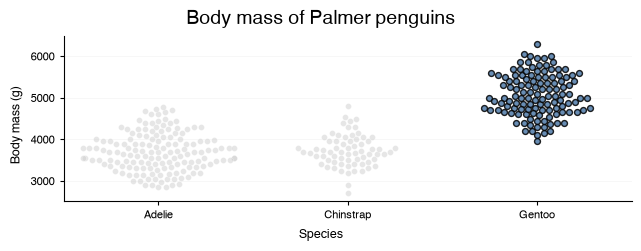

In [15]:
SwarmChart(
    data=chart_data,
    # one role per group label: Adelie, Chinstrap, Gentoo
    emphasis=[EMPHASIS.BACKGROUND, EMPHASIS.BACKGROUND, EMPHASIS.HIGHLIGHT],
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Reference lines

A reference line puts a threshold or a summary value next to the swarms. To add horizontal lines, add the `hlines` attribute with the [datachart.typings.HLinePlotAttrs](../../../references/typings/#datachart.typings.HLinePlotAttrs) typing, which is either a `dict` or a `List[dict]`; vertical lines use `vlines` and the [datachart.typings.VLinePlotAttrs](../../../references/typings/#datachart.typings.VLinePlotAttrs) typing.

In [16]:
from datachart.constants import LINE_STYLE

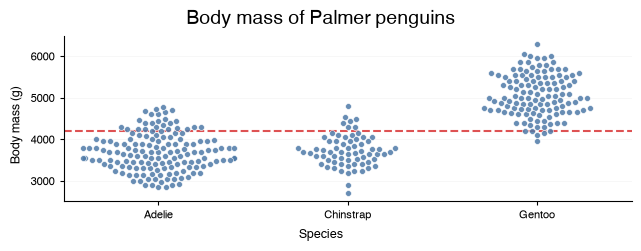

In [17]:
mean_mass = sum(penguin["value"] for penguin in chart_data) / len(chart_data)

SwarmChart(
    data=chart_data,
    # add a horizontal line at the mean body mass of all penguins
    hlines={
        "y": mean_mass,
        "style": {
            "plot_hline_color": "#d62728",
            "plot_hline_style": LINE_STYLE.DASHED,
            "plot_hline_width": 1.5,
            "plot_hline_alpha": 0.8,
        },
    },
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Overlaying a box plot

A swarm shows every observation; a box plot summarizes them. To get both, compose a [datachart.charts.BoxPlot](../../../references/charts/#datachart.charts.BoxPlot) and a `SwarmChart` of the same data with [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel): the groups share their positions, so the points sit on the box centers, and the points draw above the boxes. The box plot's outliers are already in the swarm, so hide them with `show_outliers=False`.

In [18]:
from datachart.charts import BoxPlot
from datachart.utils import Panel

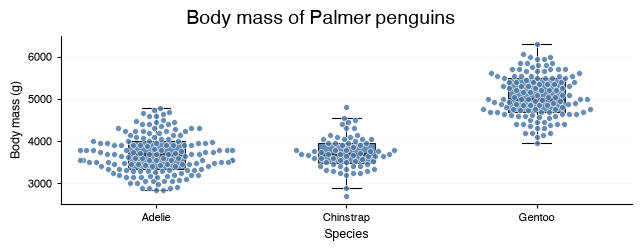

In [19]:
Panel(
    [
        # the boxes summarize the groups; the swarm already draws the outliers
        BoxPlot(data=chart_data, show_outliers=False),
        SwarmChart(data=chart_data),
    ],
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel_left="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

To keep the boxes in the background, mute the box plot figure with `emphasis` and let the points carry the color.

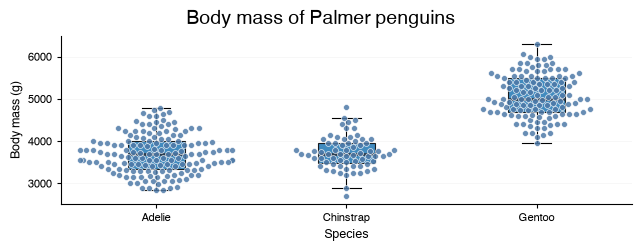

In [20]:
Panel(
    [
        # mute the boxes into context
        {"figure": BoxPlot(data=chart_data, show_outliers=False), "emphasis": EMPHASIS.BACKGROUND},
        SwarmChart(data=chart_data),
    ],
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel_left="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

## Multiple Swarm Charts

To create multiple swarm charts, pass a list of lists to the `data` argument. Each inner list holds the data points of one chart; the charts share one category axis, which lists every label in the order it first appears, and the swarms of the same label overlay at the same position in distinct colors. Per-chart attributes like `subtitle` and `style` can be passed as lists, where each element corresponds to a chart; a single value applies to every chart. The `subtitle` labels the legend.

`body_mass_by_sex` splits the penguins of the hidden cell into the 165 female and the 168 male penguins (the 9 penguins without a recorded sex are left out), one list of data points per sex.

In [21]:
SEXES = ["Female", "Male"]

# one list of data points per sex; the penguins without a recorded sex are left out
body_mass_by_sex = [
    [
        {"label": penguin["species"], "value": mass}
        for penguin in PENGUINS
        if penguin["sex"] == sex
        for mass in penguin["body_mass"]
    ]
    for sex in SEXES
]

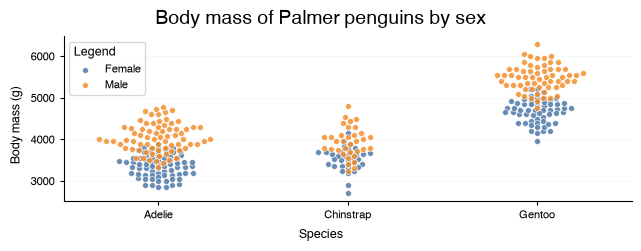

In [22]:
SwarmChart(
    # use a list of lists to define multiple swarm charts
    data=body_mass_by_sex,
    # one legend entry per chart
    subtitle=SEXES,
    title="Body mass of Palmer penguins by sex",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    show_legend=True,
).show()

### Subplots

To draw each chart in its own subplot, add the `subplots` attribute set to `True`. The `subtitle` becomes the subplot title and the `title`, `xlabel` and `ylabel` are positioned to be global for all charts. The `max_cols` attribute limits the number of columns, and `sharex` and `sharey` share an axis across the subplots; a shared axis is labeled once, on the outer subplots only.

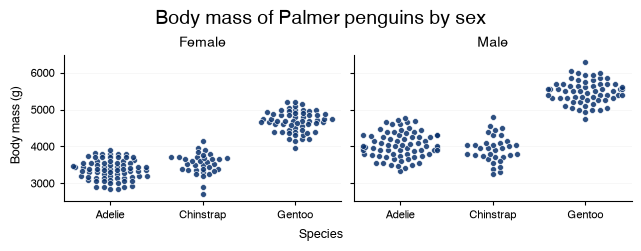

In [23]:
SwarmChart(
    data=body_mass_by_sex,
    subtitle=SEXES,
    title="Body mass of Palmer penguins by sex",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    # draw each chart in its own subplot
    subplots=True,
    # the same mass axis for both charts
    sharey=True,
).show()

## Additional Features

### Logarithmic scale

To draw the value axis on a logarithmic scale, add the `scaley` attribute with a value of the [datachart.constants.SCALE](../../../references/constants/#datachart.constants.SCALE) constant. The swarm packs the points in the scaled space, so they stay apart on the log axis as well. `flipper_data` from the hidden cell holds the flipper length (in mm) of every penguin; the span is narrow, so the log axis mostly shows that the packing follows it.

In [24]:
from datachart.constants import SCALE

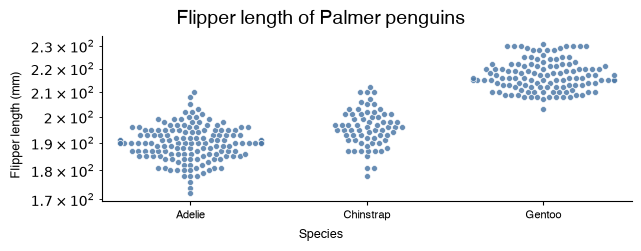

In [25]:
SwarmChart(
    data=flipper_data,
    # draw the value axis on a logarithmic scale
    scaley=SCALE.LOG,
    title="Flipper length of Palmer penguins",
    xlabel="Species",
    ylabel="Flipper length (mm)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Custom data keys

If the data points hold the label and the value under other keys, add the `label` and `value` attributes with the key names, so the data need not be reshaped.

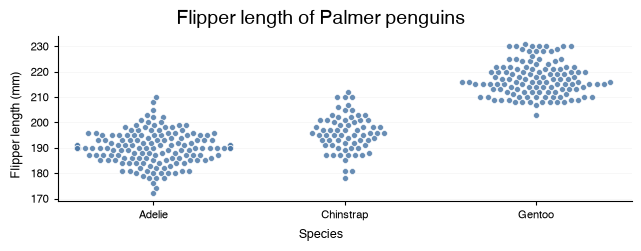

In [26]:
flipper_records = [
    {"species": penguin["species"], "flipper_mm": length}
    for penguin in PENGUINS
    for length in penguin["flipper_length"]
]

SwarmChart(
    data=flipper_records,
    # the keys holding the label and the value
    label="species",
    value="flipper_mm",
    title="Flipper length of Palmer penguins",
    xlabel="Species",
    ylabel="Flipper length (mm)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

## Saving the Chart as an Image

To save the chart as an image, use the [datachart.utils.save_figure](../../../references/utils#datachart.utils.save_figure) function.

In [27]:
from datachart.utils import save_figure

In [28]:
figure = SwarmChart(
    data=chart_data,
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
)
save_figure(figure, "./fig_swarm_chart.png", dpi=300)

The figure should be saved in the current working directory.

## Real-World Examples

The following examples put the features above to work on real or realistic data. Each one states what its data is and where it comes from; the data itself lives in a hidden cell.

### Example 1: Model Benchmark Across Seeds (Box Overlay and Emphasis)

`benchmark` holds the illustrative test accuracy of five models, each trained and evaluated with 20 random seeds, drawn from a seeded generator. A box plot alone hides that 20 seeds is a small sample; the swarm on top shows every run, so a reader can tell a tight cluster from a wide one that happens to share a median. The best model is highlighted in both layers, the rest muted.

In [29]:
import numpy as np

rng = np.random.RandomState(7)

# mean and standard deviation of the test accuracy of each model across seeds
MODELS = {
    "Baseline": (0.812, 0.020),
    "Wide": (0.838, 0.015),
    "Deep": (0.851, 0.025),
    "Deep + aug.": (0.872, 0.012),
    "Ensemble": (0.864, 0.008),
}
N_SEEDS = 20

benchmark = [
    {"label": model, "value": float(np.clip(rng.normal(mean, std), 0, 1))}
    for model, (mean, std) in MODELS.items()
    for _ in range(N_SEEDS)
]

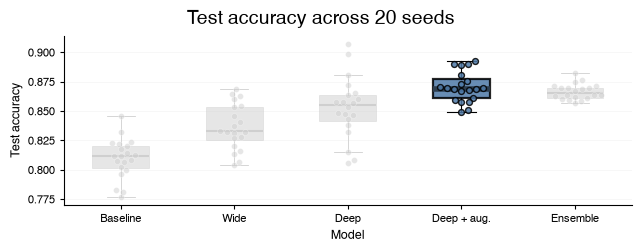

In [30]:
BEST_MODEL = "Deep + aug."
roles = [EMPHASIS.HIGHLIGHT if model == BEST_MODEL else EMPHASIS.BACKGROUND for model in MODELS]

Panel(
    [
        BoxPlot(data=benchmark, show_outliers=False, emphasis=roles),
        # the same roles align with the same labels in both layers
        SwarmChart(data=benchmark, emphasis=roles),
    ],
    title=f"Test accuracy across {N_SEEDS} seeds",
    xlabel="Model",
    ylabel_left="Test accuracy",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Example 2: Service Response Times (Strip Mode, Log Scale and an SLA Line)

`response_times` holds the illustrative response time (in ms) of 300 requests to each of four services, drawn from a seeded log-normal generator: most requests are fast and a long tail of slow ones stretches each distribution. On a log axis the tail reads at the same resolution as the bulk, and with 1,200 points the strip mode spreads them evenly instead of packing a swarm that would fill its width anyway. The horizontal line marks the service level agreement, so the requests that breach it are the points above it.

In [31]:
rng = np.random.RandomState(5)

# log-normal parameters (mean and sigma of the log) of the response time of each service
SERVICES = {
    "Auth": (4.6, 0.25),
    "Search": (5.3, 0.45),
    "Checkout": (5.0, 0.35),
    "Reports": (5.6, 0.55),
}
N_REQUESTS = 300
SLA_MS = 500

response_times = [
    {"label": service, "value": float(rng.lognormal(mean, sigma))}
    for service, (mean, sigma) in SERVICES.items()
    for _ in range(N_REQUESTS)
]

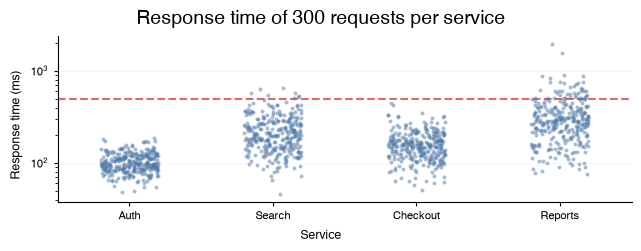

In [32]:
SwarmChart(
    data=response_times,
    # jitter the many points evenly across the category width
    mode=SWARM_MODE.STRIP,
    # the long tail reads at the same resolution as the bulk
    scaley=SCALE.LOG,
    # mark the service level agreement
    hlines={
        "y": SLA_MS,
        "style": {
            "plot_hline_color": "#d62728",
            "plot_hline_style": LINE_STYLE.DASHED,
            "plot_hline_width": 1.5,
        },
    },
    style={"plot_swarm_size": 8, "plot_swarm_alpha": 0.5, "plot_swarm_edge_width": 0},
    title=f"Response time of {N_REQUESTS} requests per service",
    xlabel="Service",
    ylabel="Response time (ms)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Example 3: Daily Temperatures by Month (Horizontal Swarms and Many Categories)

`daily_temperatures` holds one year of daily mean temperatures (in °C) in Ljubljana, drawn from a seeded generator around the published 1991–2020 monthly climate normals of the city's weather station, with the larger day-to-day swings of the winter months. Twelve labeled swarms read best top to bottom, and a vertical line marks the freezing point, so the days below zero are the points to its left.

In [33]:
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
DAYS_IN_MONTH = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]

# mean monthly temperature in °C, 1991–2020 climate normals of Ljubljana
LJUBLJANA_NORMALS = [0.8, 2.4, 6.8, 11.5, 16.2, 20.1, 22.0, 21.4, 16.5, 11.6, 6.1, 1.5]
# day-to-day spread in °C, larger in winter
DAILY_SPREAD = [3.5, 3.5, 3.0, 2.8, 2.5, 2.2, 2.0, 2.0, 2.5, 2.8, 3.0, 3.5]

rng = np.random.RandomState(11)

daily_temperatures = [
    {"label": month, "value": float(rng.normal(normal, spread))}
    for month, days, normal, spread in zip(MONTHS, DAYS_IN_MONTH, LJUBLJANA_NORMALS, DAILY_SPREAD)
    for _ in range(days)
]

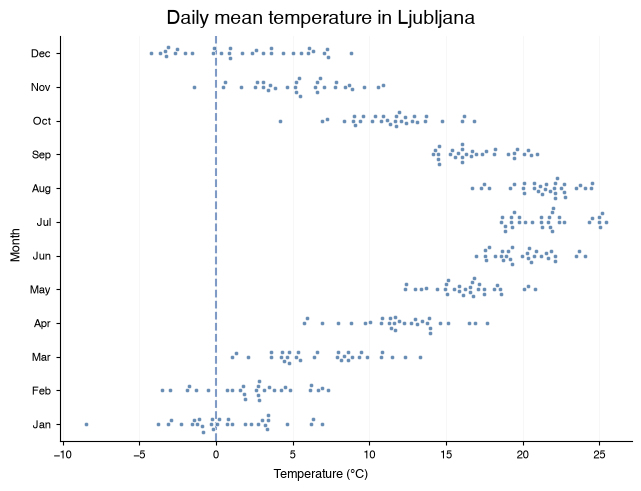

In [34]:
SwarmChart(
    data=daily_temperatures,
    # twelve labeled swarms read best top to bottom
    orientation=ORIENTATION.HORIZONTAL,
    # mark the freezing point
    vlines={
        "x": 0,
        "style": {
            "plot_vline_color": "#4c72b0",
            "plot_vline_style": LINE_STYLE.DASHED,
            "plot_vline_width": 1.5,
        },
    },
    style={"plot_swarm_size": 10},
    title="Daily mean temperature in Ljubljana",
    xlabel="Temperature (°C)",
    ylabel="Month",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_grid=SHOW_GRID.X,
).show()